In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv(r"C:\Users\Lisa\Downloads\ilc_pw01__custom_21258735_linear_2_0.csv")

In [6]:
#structure of the data
print(df.head())
print(df.columns)
print(df.shape) 

  STRUCTURE         STRUCTURE_ID  \
0  dataflow  ESTAT:ILC_PW01(1.0)   
1  dataflow  ESTAT:ILC_PW01(1.0)   
2  dataflow  ESTAT:ILC_PW01(1.0)   
3  dataflow  ESTAT:ILC_PW01(1.0)   
4  dataflow  ESTAT:ILC_PW01(1.0)   

                                      STRUCTURE_NAME freq Time frequency  \
0  Overall life satisfaction by sex, age and educ...    A         Annual   
1  Overall life satisfaction by sex, age and educ...    A         Annual   
2  Overall life satisfaction by sex, age and educ...    A         Annual   
3  Overall life satisfaction by sex, age and educ...    A         Annual   
4  Overall life satisfaction by sex, age and educ...    A         Annual   

  statinfo Statistical information unit Unit of measure isced11  ... geo  \
0      AVG                 Average  RTG   Rating (0-10)   ED0-2  ...  AL   
1      AVG                 Average  RTG   Rating (0-10)   ED0-2  ...  AL   
2      AVG                 Average  RTG   Rating (0-10)   ED0-2  ...  AL   
3      AVG            

In [7]:
#data types and missing values
print(df.info())
print(df.isna().sum())
print(df.sample(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38064 entries, 0 to 38063
Data columns (total 27 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   STRUCTURE                                                        38064 non-null  object 
 1   STRUCTURE_ID                                                     38064 non-null  object 
 2   STRUCTURE_NAME                                                   38064 non-null  object 
 3   freq                                                             38064 non-null  object 
 4   Time frequency                                                   38064 non-null  object 
 5   statinfo                                                         38064 non-null  object 
 6   Statistical information                                          38064 non-null  object 
 7   unit                                    

In [8]:
#visualisation of the data
df.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,statinfo,Statistical information,unit,Unit of measure,isced11,...,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:ILC_PW01(1.0),"Overall life satisfaction by sex, age and educ...",A,Annual,AVG,Average,RTG,Rating (0-10),ED0-2,...,AL,Albania,2018,NaN,6.3,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:ILC_PW01(1.0),"Overall life satisfaction by sex, age and educ...",A,Annual,AVG,Average,RTG,Rating (0-10),ED0-2,...,AL,Albania,2021,NaN,6.3,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:ILC_PW01(1.0),"Overall life satisfaction by sex, age and educ...",A,Annual,AVG,Average,RTG,Rating (0-10),ED0-2,...,AL,Albania,2022,NaN,6.6,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:ILC_PW01(1.0),"Overall life satisfaction by sex, age and educ...",A,Annual,AVG,Average,RTG,Rating (0-10),ED0-2,...,AL,Albania,2023,NaN,6.9,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:ILC_PW01(1.0),"Overall life satisfaction by sex, age and educ...",A,Annual,AVG,Average,RTG,Rating (0-10),ED0-2,...,AT,Austria,2013,NaN,8.4,NaN,NaN,NaN,NaN,NaN


In [9]:
#renaming columns for better readability
df = df.rename(columns={
    "geo": "country",
    "sex": "sex",
    "age": "age_group",
    "isced11": "education",
    "TIME_PERIOD": "year",
    "OBS_VALUE": "life_satisfaction"
})

In [10]:
#selecting only the relevant columns for our analysis
df = df[["country", "sex", "age_group", "education", "year", "life_satisfaction"]]

In [11]:
#missing values 
df = df.dropna(subset=["life_satisfaction"])

In [12]:
#check the variables type
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["life_satisfaction"] = pd.to_numeric(df["life_satisfaction"], errors="coerce")

In [13]:
# drop rows with missing values in 'year' or 'life_satisfaction'
df = df.dropna(subset=["year", "life_satisfaction"])

In [14]:
# check for duplicates
df.duplicated().any()

np.False_

In [15]:
#filtering the data for the year 2024 and total population
df_filtered = df[
    (df["year"] == 2024) &
    (df["sex"] == "T")
].copy()

In [16]:
#check the unique values in the categorical columns
print(df["sex"].unique())
print(df["age_group"].unique())
print(df["education"].unique())

['F' 'M' 'T']
['Y16-19' 'Y16-24' 'Y16-29' 'Y20-24' 'Y25-29' 'Y25-34' 'Y25-64' 'Y35-49'
 'Y50-64' 'Y65-74' 'Y_GE16' 'Y_GE65' 'Y_GE75']
['ED0-2' 'ED3_4' 'ED5-8' 'TOTAL']


In [17]:
#filtering the data for the relevant age groups and education levels
selected_ages = [
    "Y16-24",
    "Y25-34",
    "Y35-49",
    "Y50-64",
    "Y_GE65"
]

selected_education = [
    "ED0-2",
    "ED3_4",
    "ED5-8"
]

df_filtered = df_filtered[
    df_filtered["age_group"].isin(selected_ages) &
    df_filtered["education"].isin(selected_education)
].copy()

In [18]:
#final check of the filtered data
print(df_filtered.head())
print(df_filtered.shape)
print(df_filtered["country"].nunique())
print(df_filtered["age_group"].unique())
print(df_filtered["education"].unique())

     country sex age_group education  year  life_satisfaction
6597      AT   T    Y16-24     ED0-2  2024                7.7
6604      BE   T    Y16-24     ED0-2  2024                7.8
6611      BG   T    Y16-24     ED0-2  2024                6.9
6618      CH   T    Y16-24     ED0-2  2024                7.6
6624      CY   T    Y16-24     ED0-2  2024                7.9
(510, 6)
34
['Y16-24' 'Y25-34' 'Y35-49' 'Y50-64' 'Y_GE65']
['ED0-2' 'ED3_4' 'ED5-8']


In [42]:
#calculate the mean life satisfaction by education level
mean_by_education = df_filtered.groupby("education")["life_satisfaction"].mean().sort_values()
print(mean_by_education)

education_labels = {
    "ED0-2": "Low education",
    "ED3_4": "Medium education",
    "ED5-8": "Tertiary education"
}

mean_by_education_table = (
    mean_by_education.rename(index=education_labels)
    .rename("Average life satisfaction")
    .to_frame()
)
mean_by_education_table.index.name = "Education level"
mean_by_education_table = mean_by_education_table.round(3)

display(mean_by_education_table)

mean_by_education_table.to_csv("table_mean_life_satisfaction_by_education.csv")

education
ED0-2    6.841765
ED3_4    7.247059
ED5-8    7.607059
Name: life_satisfaction, dtype: float64


,Average life satisfaction
Education level,
Low education,6.842
Medium education,7.247
Tertiary education,7.607


In [47]:
#calculate the mean life satisfaction by age group
mean_by_age = df_filtered.groupby("age_group")["life_satisfaction"].mean().sort_values()
print(mean_by_age)
mean_by_age = mean_by_age.reindex(age_labels.keys())
mean_by_age_table = (
    mean_by_age.rename(index=age_labels)
    .rename("Average life satisfaction")
    .to_frame()
)
mean_by_age_table.index.name = "Age group"
mean_by_age_table = mean_by_age_table.round(3)

display(mean_by_age_table)

mean_by_age_table.to_csv("table_mean_life_satisfaction_by_age_group.csv")

age_group
Y50-64    7.061765
Y_GE65    7.105882
Y35-49    7.149020
Y25-34    7.205882
Y16-24    7.637255
Name: life_satisfaction, dtype: float64


,Average life satisfaction
Age group,
16-24,7.637
25-34,7.206
35-49,7.149
50-64,7.062
65+,7.106


In [53]:
#calculate the mean life satisfaction by country
mean_by_country = df_filtered.groupby("country")["life_satisfaction"].mean().sort_values()
print(mean_by_country.head(10))   # les plus faibles
print(mean_by_country.tail(10))   # les plus élevés



country
TR    5.893333
MK    6.286667
BG    6.400000
RS    6.560000
EL    6.853333
LV    6.926667
DE    7.000000
EE    7.053333
HU    7.120000
LU    7.153333
Name: life_satisfaction, dtype: float64
country
NL    7.513333
NO    7.513333
AT    7.520000
BE    7.540000
CH    7.560000
MT    7.566667
PL    7.566667
SI    7.720000
FI    7.753333
RO    7.820000
Name: life_satisfaction, dtype: float64


In [51]:
#create a pivot table to analyze the interaction between age group and education level on life satisfaction
pivot_age_edu = df_filtered.pivot_table(
    values="life_satisfaction",
    index="age_group",
    columns="education",
    aggfunc="mean"
)

print(pivot_age_edu)
pivot_age_edu = pivot_age_edu.rename(index=age_labels, columns=education_labels)
pivot_age_edu.to_csv("table_pivot_age_education.csv")
display(pivot_age_edu)

education     ED0-2     ED3_4     ED5-8
age_group                              
Y16-24     7.626471  7.567647  7.717647
Y25-34     6.670588  7.261765  7.685294
Y35-49     6.652941  7.185294  7.608824
Y50-64     6.555882  7.091176  7.538235
Y_GE65     6.702941  7.129412  7.485294


education,Low education,Medium education,Tertiary education
age_group,,,
16-24,7.626471,7.567647,7.717647
25-34,6.670588,7.261765,7.685294
35-49,6.652941,7.185294,7.608824
50-64,6.555882,7.091176,7.538235
65+,6.702941,7.129412,7.485294


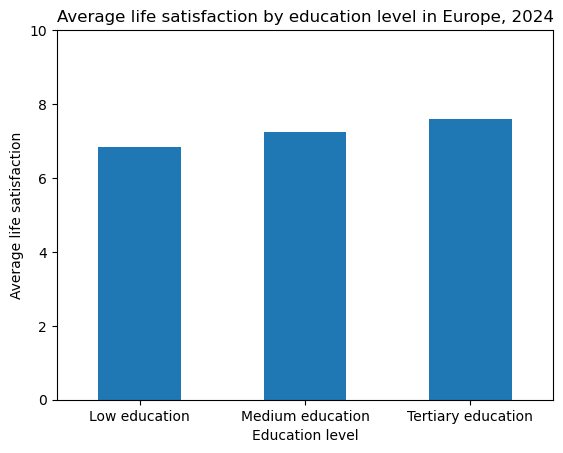

In [23]:
#Figure 1: Average life satisfaction by education level

import matplotlib.pyplot as plt

# Calculate average life satisfaction by education level
mean_by_education = df_filtered.groupby("education")["life_satisfaction"].mean()

# Rename education categories for clearer labels
education_labels = {
    "ED0-2": "Low education",
    "ED3_4": "Medium education",
    "ED5-8": "Tertiary education"
}

mean_by_education = mean_by_education.rename(index=education_labels)

# Create the bar chart
mean_by_education.plot(kind="bar")

plt.title("Average life satisfaction by education level in Europe, 2024")
plt.xlabel("Education level")
plt.ylabel("Average life satisfaction")
plt.ylim(0, 10)
plt.xticks(rotation=0)

# Save the figure
plt.savefig("figure_1_life_satisfaction_by_education.png", dpi=300, bbox_inches="tight")

plt.show()

In [24]:
#Figure 2 & 3: Country ranking by average life satisfaction

# Calculate average life satisfaction by country
mean_by_country = df_filtered.groupby("country")["life_satisfaction"].mean().sort_values()

# Display the result
mean_by_country

country
TR           5.893333
MK           6.286667
BG           6.400000
RS           6.560000
EL           6.853333
LV           6.926667
DE           7.000000
EE           7.053333
HU           7.120000
LU           7.153333
FR           7.166667
SK           7.186667
LT           7.213333
EA20         7.226667
EU27_2020    7.266667
ES           7.280000
IT           7.320000
HR           7.340000
SE           7.380000
CY           7.393333
CZ           7.426667
DK           7.440000
IE           7.453333
PT           7.473333
NL           7.513333
NO           7.513333
AT           7.520000
BE           7.540000
CH           7.560000
MT           7.566667
PL           7.566667
SI           7.720000
FI           7.753333
RO           7.820000
Name: life_satisfaction, dtype: float64

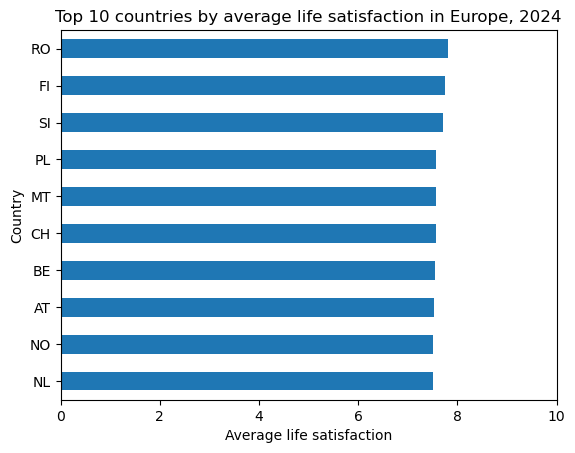

In [25]:
import matplotlib.pyplot as plt

# Select the 10 countries with the highest average life satisfaction
top_10_countries = mean_by_country.tail(10)

# Create the bar chart
top_10_countries.plot(kind="barh")

plt.title("Top 10 countries by average life satisfaction in Europe, 2024")
plt.xlabel("Average life satisfaction")
plt.ylabel("Country")
plt.xlim(0, 10)

plt.savefig("figure_2_top_10_countries_life_satisfaction.png", dpi=300, bbox_inches="tight")

plt.show()

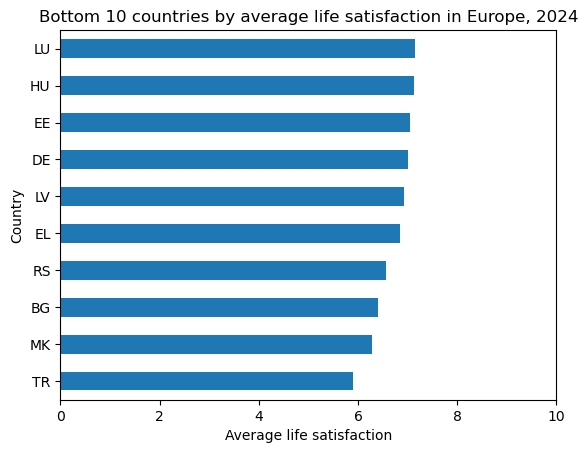

In [26]:
import matplotlib.pyplot as plt

# Select the 10 countries with the lowest average life satisfaction
bottom_10_countries = mean_by_country.head(10)

# Create the bar chart
bottom_10_countries.plot(kind="barh")

plt.title("Bottom 10 countries by average life satisfaction in Europe, 2024")
plt.xlabel("Average life satisfaction")
plt.ylabel("Country")
plt.xlim(0, 10)

plt.savefig("figure_3_bottom_10_countries_life_satisfaction.png", dpi=300, bbox_inches="tight")

plt.show()

In [27]:
# Display top and bottom countries with exact values
print("Top 10 countries:")
print(top_10_countries.sort_values(ascending=False))

print("\nBottom 10 countries:")
print(bottom_10_countries)

Top 10 countries:
country
RO    7.820000
FI    7.753333
SI    7.720000
MT    7.566667
PL    7.566667
CH    7.560000
BE    7.540000
AT    7.520000
NL    7.513333
NO    7.513333
Name: life_satisfaction, dtype: float64

Bottom 10 countries:
country
TR    5.893333
MK    6.286667
BG    6.400000
RS    6.560000
EL    6.853333
LV    6.926667
DE    7.000000
EE    7.053333
HU    7.120000
LU    7.153333
Name: life_satisfaction, dtype: float64


In [28]:
#Figure 4: Average life satisfaction by age group and education level

import seaborn as sns
import matplotlib.pyplot as plt

pivot_age_edu = df_filtered.pivot_table(
    values="life_satisfaction",
    index="age_group",
    columns="education",
    aggfunc="mean"
)

pivot_age_edu

education,ED0-2,ED3_4,ED5-8
age_group,,,
Y16-24,7.626471,7.567647,7.717647
Y25-34,6.670588,7.261765,7.685294
Y35-49,6.652941,7.185294,7.608824
Y50-64,6.555882,7.091176,7.538235
Y_GE65,6.702941,7.129412,7.485294


In [29]:
pivot_age_edu = pivot_age_edu.rename(columns={
    "ED0-2": "Low education",
    "ED3_4": "Medium education",
    "ED5-8": "Tertiary education"
})

pivot_age_edu

education,Low education,Medium education,Tertiary education
age_group,,,
Y16-24,7.626471,7.567647,7.717647
Y25-34,6.670588,7.261765,7.685294
Y35-49,6.652941,7.185294,7.608824
Y50-64,6.555882,7.091176,7.538235
Y_GE65,6.702941,7.129412,7.485294


In [30]:
pivot_age_edu = pivot_age_edu.rename(index={
    "Y16-24": "16-24",
    "Y25-34": "25-34",
    "Y35-49": "35-49",
    "Y50-64": "50-64",
    "Y_GE65": "65+"
})

pivot_age_edu

education,Low education,Medium education,Tertiary education
age_group,,,
16-24,7.626471,7.567647,7.717647
25-34,6.670588,7.261765,7.685294
35-49,6.652941,7.185294,7.608824
50-64,6.555882,7.091176,7.538235
65+,6.702941,7.129412,7.485294


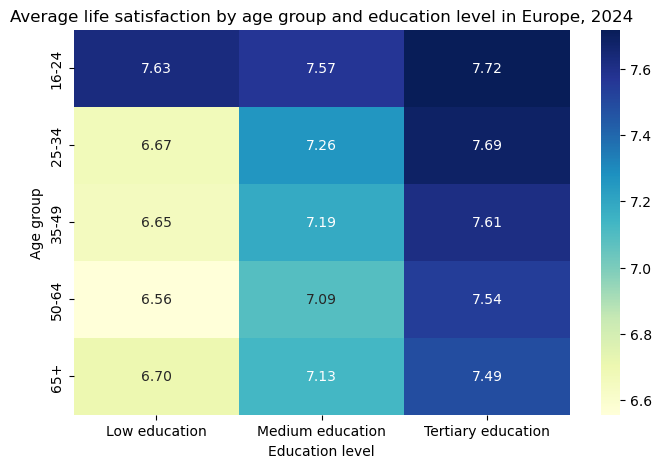

In [31]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    pivot_age_edu,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average life satisfaction by age group and education level in Europe, 2024")
plt.xlabel("Education level")
plt.ylabel("Age group")

plt.savefig("figure_4_heatmap_age_education_life_satisfaction.png", dpi=300, bbox_inches="tight")

plt.show()

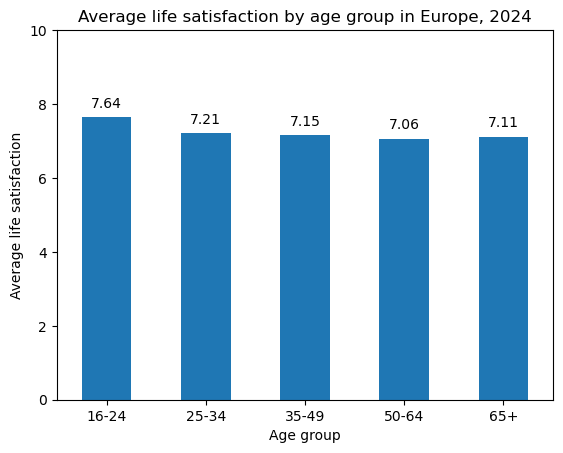

In [32]:
#bar chart with age groups 
mean_by_age = df_filtered.groupby("age_group")["life_satisfaction"].mean().sort_values()
age_labels = {
    "Y16-24": "16-24",
    "Y25-34": "25-34",
    "Y35-49": "35-49",
    "Y50-64": "50-64",
    "Y_GE65": "65+"
}
mean_by_age = mean_by_age.reindex(age_labels.keys())
mean_by_age = mean_by_age.rename(index=age_labels)
ax = mean_by_age.plot(kind="bar")
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.title("Average life satisfaction by age group in Europe, 2024")
plt.xlabel("Age group")
plt.ylabel("Average life satisfaction")
plt.ylim(0, 10)
plt.xticks(rotation=0)
plt.savefig("figure_5_life_satisfaction_by_age_group.png", dpi=300,
            bbox_inches="tight")
plt.show()



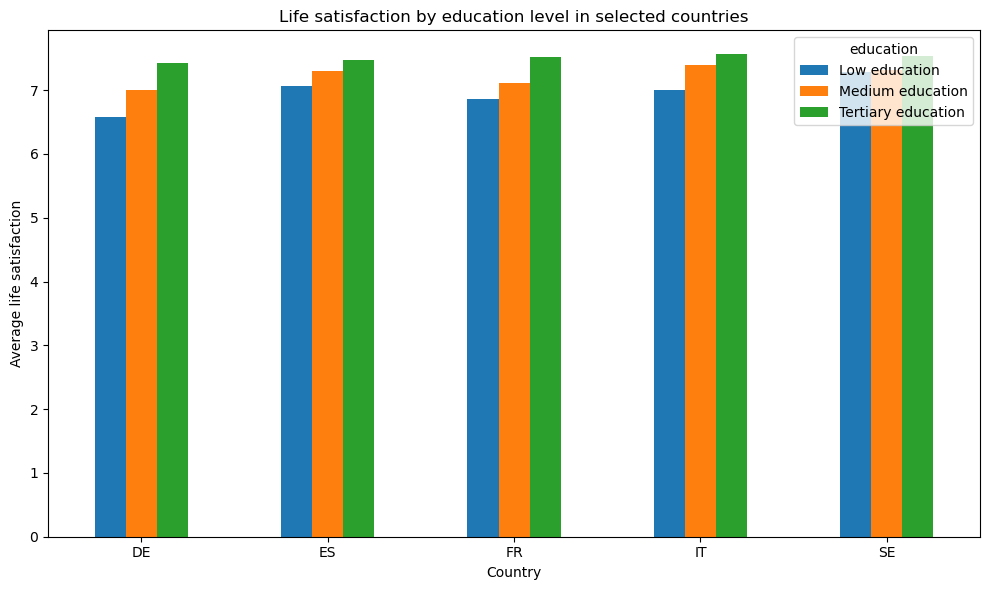

In [33]:
#bar chart with education levels by country
selected_countries = ["FR", "DE", "IT", "ES", "SE"]

subset_country_edu = df_filtered[df_filtered["country"].isin(selected_countries)]
plot_data = subset_country_edu.groupby(["country", "education"])["life_satisfaction"].mean().unstack()
plot_data = plot_data.rename(columns=education_labels)
plot_data.plot(kind="bar", figsize=(10, 6))
plt.title("Life satisfaction by education level in selected countries")
plt.xlabel("Country")
plt.ylabel("Average life satisfaction")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [34]:
#Regression analysis to explore the relationship between life satisfaction, age, and education level
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Prepare the data for regression
df_reg = df_filtered.copy()

df_reg["education"] = df_reg["education"].astype("category")
df_reg["age_group"] = df_reg["age_group"].astype("category")
df_reg["country"] = df_reg["country"].astype("category")

In [35]:
# Model 1: Life satisfaction as a function of education level only
import statsmodels.formula.api as smf

model1 = smf.ols("life_satisfaction ~ C(education, Treatment(reference='ED0-2'))", data=df_reg).fit()
print(model1.summary())

with open("model1_regression_summary.txt", "w", encoding="utf-8") as f:
    f.write(model1.summary().as_text())

model1_coefficients = model1.summary2().tables[1]
model1_coefficients.to_csv("model1_regression_coefficients.csv", index=True)





                            OLS Regression Results                            
Dep. Variable:      life_satisfaction   R-squared:                       0.219
Model:                            OLS   Adj. R-squared:                  0.216
Method:                 Least Squares   F-statistic:                     71.08
Date:                Sun, 03 May 2026   Prob (F-statistic):           6.14e-28
Time:                        15:53:44   Log-Likelihood:                -454.88
No. Observations:                 510   AIC:                             915.8
Df Residuals:                     507   BIC:                             928.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------

In [36]:
# Model 2: Life satisfaction as a function of education level and age group
model2 = smf.ols("life_satisfaction ~ C(education, Treatment(reference='ED0-2')) + C(age_group, Treatment(reference='Y16-24'))", data=df_reg).fit()
print(model2.summary())

with open("model2_regression_summary.txt", "w", encoding="utf-8") as f:
    f.write(model2.summary().as_text())
model2_coefficients = model2.summary2().tables[1]
model2_coefficients.to_csv("model2_regression_coefficients.csv", index=True)



                            OLS Regression Results                            
Dep. Variable:      life_satisfaction   R-squared:                       0.316
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     38.75
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.03e-38
Time:                        15:53:44   Log-Likelihood:                -421.02
No. Observations:                 510   AIC:                             856.0
Df Residuals:                     503   BIC:                             885.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

                            OLS Regression Results                            
Dep. Variable:      life_satisfaction   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     28.77
Date:                Sun, 03 May 2026   Prob (F-statistic):           7.06e-95
Time:                        15:54:27   Log-Likelihood:                -203.84
No. Observations:                 480   AIC:                             483.7
Df Residuals:                     442   BIC:                             642.3
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

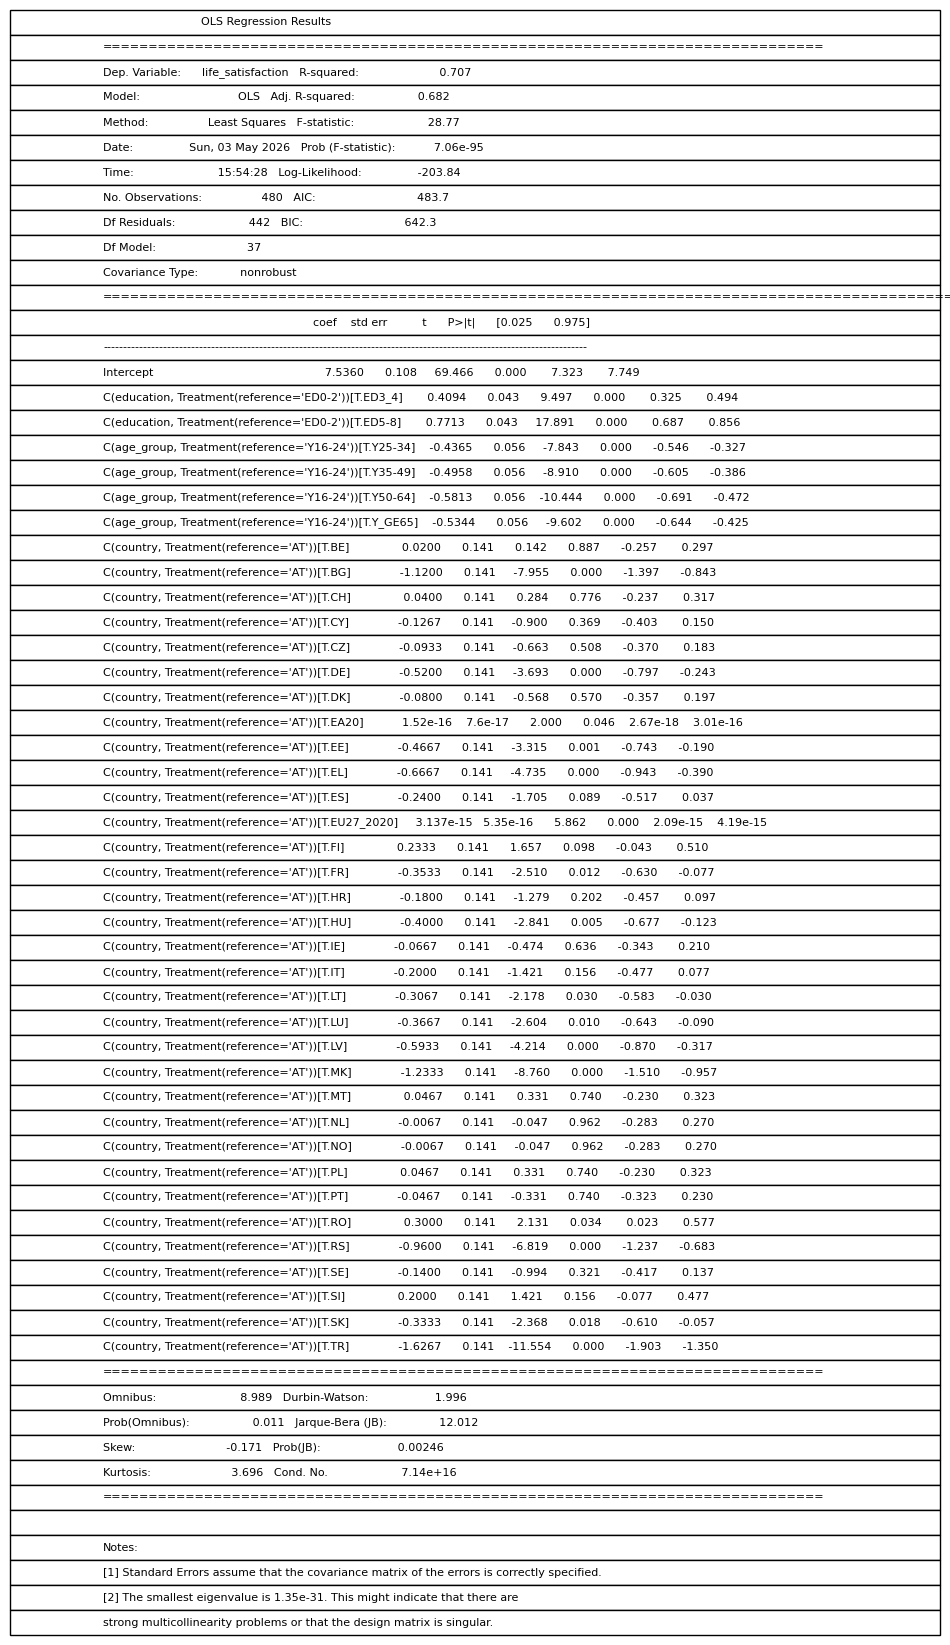

In [40]:

# Model 3: Life satisfaction as a function of education level, age group, and country

df_reg = df_reg[~df_reg["country"].isin(["EU27_2020", "EA20"])].copy()

model3 = smf.ols("life_satisfaction ~ C(education, Treatment(reference='ED0-2')) + C(age_group, Treatment(reference='Y16-24')) + C(country, Treatment(reference='AT'))", data=df_reg).fit()
print(model3.summary())

with open("model3_regression_summary.txt", "w", encoding="utf-8") as f:
    f.write(model3.summary().as_text())
model3_coefficients = model3.summary2().tables[1]
model3_coefficients.to_csv("model3_regression_coefficients.csv", index=True)

# Create a table image of Model 3 regression results

# Get summary table
summary = model3.summary()

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('tight')
ax.axis('off')

# Convert summary to text and create table
table_data = []
for line in str(summary).split('\n'):
    table_data.append([line])

# Create table
table = ax.table(cellText=table_data, cellLoc='left', loc='center',
                colWidths=[1])
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)

plt.savefig("model3_regression_results_table.png", dpi=300, bbox_inches="tight")
plt.show()


                            OLS Regression Results                            
Dep. Variable:      life_satisfaction   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.731
Method:                 Least Squares   F-statistic:                     30.44
Date:                Sun, 03 May 2026   Prob (F-statistic):          5.50e-113
Time:                        15:53:47   Log-Likelihood:                -158.31
No. Observations:                 510   AIC:                             412.6
Df Residuals:                     462   BIC:                             615.9
Df Model:                          47                                         
Covariance Type:            nonrobust                                         
                                                                                                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

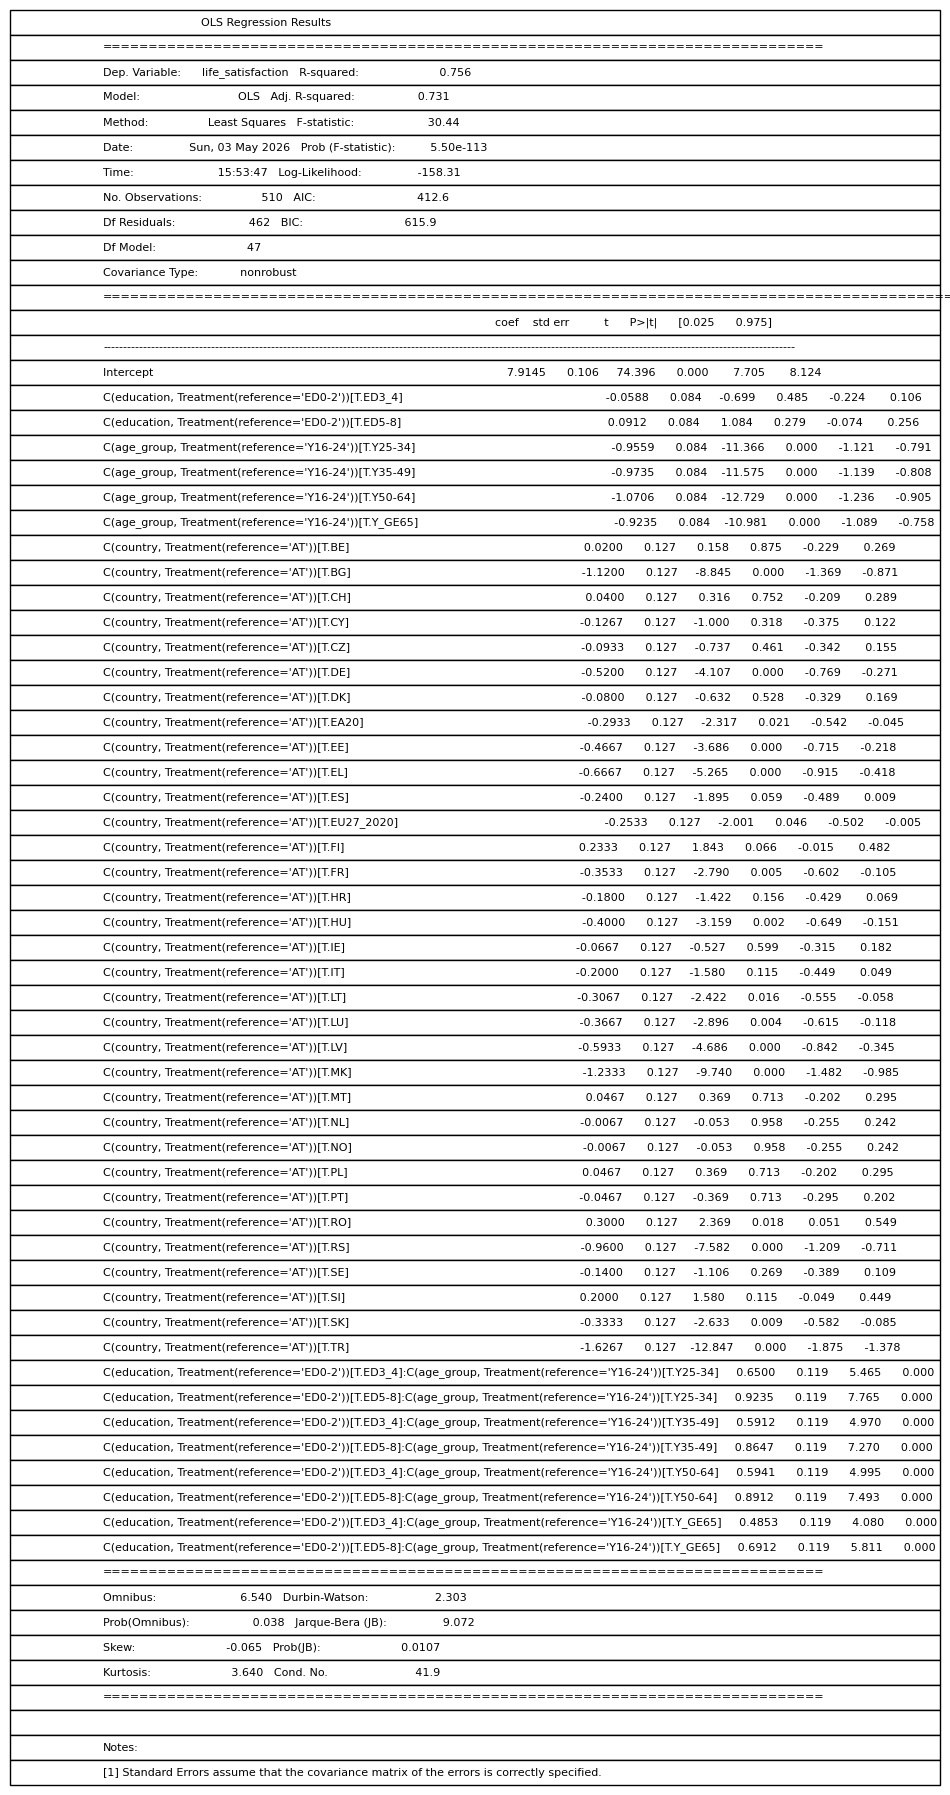

In [38]:
# Model 4: Life satisfaction as a function of education level, age group, and country
model4 = smf.ols("life_satisfaction ~ C(education, Treatment(reference='ED0-2')) * C(age_group, Treatment(reference='Y16-24')) + C(country, Treatment(reference='AT'))", data=df_reg).fit()
print(model4.summary())

with open("model4_regression_summary.txt", "w", encoding="utf-8") as f:
    f.write(model4.summary().as_text())
model4_coefficients = model4.summary2().tables[1]
model4_coefficients.to_csv("model4_regression_coefficients.csv", index=True)

# Create a table image of Model 4 regression results
summary = model4.summary()
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('tight')
ax.axis('off')
table_data = []
for line in str(summary).split('\n'):
    table_data.append([line])
table = ax.table(cellText=table_data, cellLoc='left', loc='center',
                colWidths=[1])
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)
plt.savefig("model4_regression_results_table.png", dpi=300, bbox_inches="tight")
plt.show()


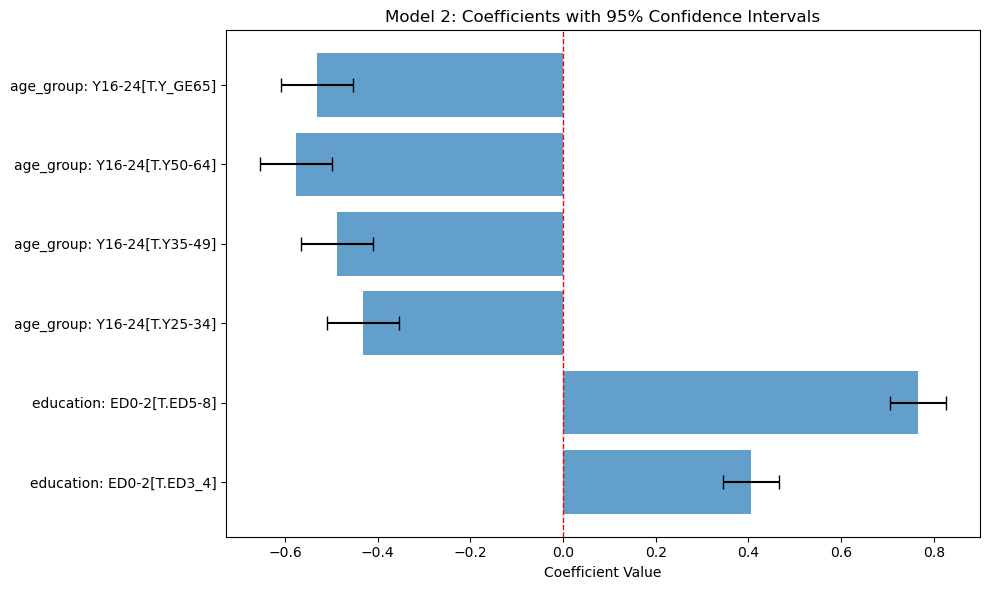

In [39]:
# Create coefficient plot for Model 2
fig, ax = plt.subplots(figsize=(10, 6))
y_pred = model2.predict(df_reg)
coefficients = model2_coefficients['Coef.'].iloc[1:]  # Exclude intercept
errors = model2_coefficients['Std.Err.'].iloc[1:]

y_pos = np.arange(len(coefficients))
ax.barh(y_pos, coefficients, xerr=errors, capsize=5, alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels([label.replace('C(', '').replace(', Treatment(reference=\'', ': ').replace('\'))', '') for label in coefficients.index])
ax.set_xlabel('Coefficient Value')
ax.set_title('Model 2: Coefficients with 95% Confidence Intervals')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig("figure_6_model2_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()




